# Customer Churn Prediction (Bank Customers)

## Objective
Predict customers who are likely to leave the bank.

## Business Problem
Customer churn directly impacts revenue. Retaining existing customers is significantly cheaper than acquiring new ones.

This model helps:
- Identify high-risk customers
- Improve retention strategies
- Increase customer lifetime value

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

In [3]:
df = pd.read_csv("churn_Modelling.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower()

df.head()

,rownumber,customerid,surname,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rownumber        10000 non-null  int64  
 1   customerid       10000 non-null  int64  
 2   surname          10000 non-null  object 
 3   creditscore      10000 non-null  int64  
 4   geography        10000 non-null  object 
 5   gender           10000 non-null  object 
 6   age              10000 non-null  int64  
 7   tenure           10000 non-null  int64  
 8   balance          10000 non-null  float64
 9   numofproducts    10000 non-null  int64  
 10  hascrcard        10000 non-null  int64  
 11  isactivemember   10000 non-null  int64  
 12  estimatedsalary  10000 non-null  float64
 13  exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


rownumber          0
customerid         0
surname            0
creditscore        0
geography          0
gender             0
age                0
tenure             0
balance            0
numofproducts      0
hascrcard          0
isactivemember     0
estimatedsalary    0
exited             0
dtype: int64

Dataset contains customer demographics, account details, and churn status. No major missing values are expected.

In [5]:
# Drop unnecessary columns
df.drop(['rownumber', 'customerid', 'surname'], axis=1, inplace=True)

In [29]:
# Reload fresh dataset
df = pd.read_csv("Churn_Modelling.csv")
df.columns = df.columns.str.strip().str.lower()

In [6]:
# Label encoding for Gender
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

One-hot encoding avoids ordinal bias in geography, while gender is binary and safely label encoded.

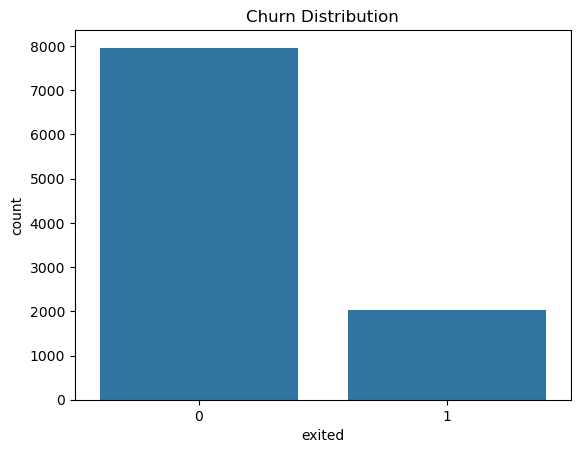

In [7]:
sns.countplot(x='exited', data=df)
plt.title("Churn Distribution")
plt.show


The dataset is imbalanced, with fewer churned customers. This can bias the model toward predicting non-churn cases.

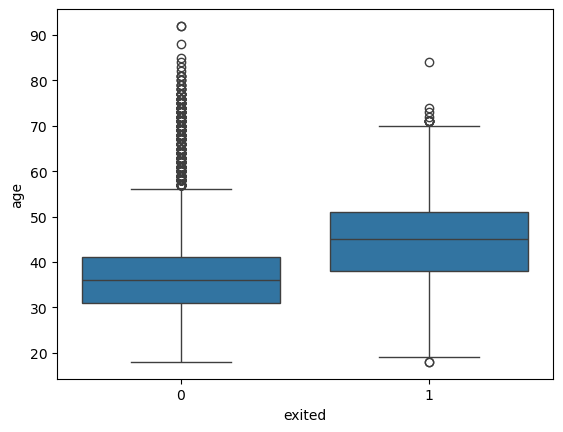

In [8]:
sns.boxplot(x='exited', y='age', data=df)
plt.show()

### Insight:

Older customers tend to churn more frequently than younger customers.

This may indicate:
- Changing financial needs
- Migration to competitor banks
- Lower engagement with digital banking services

Age is a strong predictor of churn behavior.

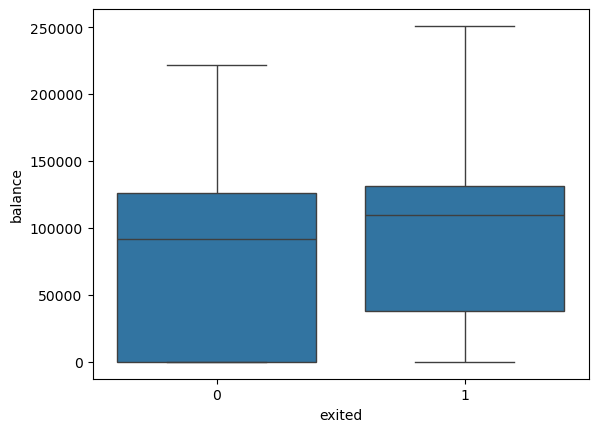

In [9]:
sns.boxplot(x='exited', y='balance', data=df)
plt.show()

### Insight:

Customers with higher account balances show a higher tendency to churn.

This is critical because:
- High-balance customers are high-value clients
- Losing them results in significant financial loss

This group should be prioritized for retention strategies.

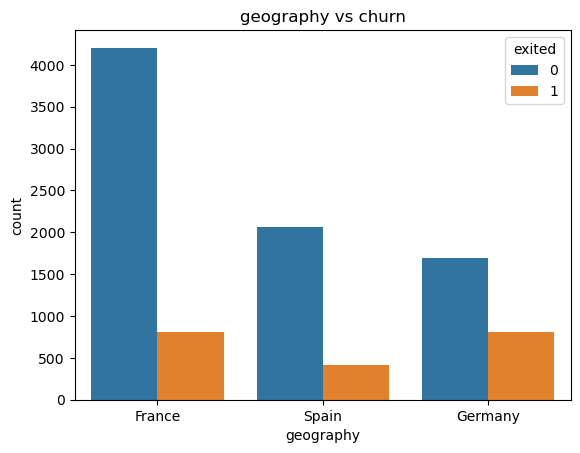

In [28]:
sns.countplot(x='geography', hue='exited', data=df)
plt.title("geography vs churn")
plt.show()

### Insight:

Customers from Germany exhibit a significantly higher churn rate compared to France and Spain.

This indicates potential regional issues such as:
- Competitive banking options
- Customer dissatisfaction
- Pricing or service differences

Geography is an important segmentation variable for targeted retention strategies.

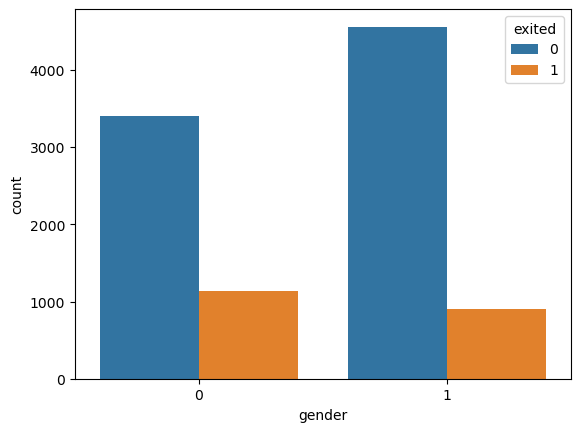

In [26]:
sns.countplot(x='gender', hue='exited', data=df)
plt.show()

### Insight:

Female customers show a slightly higher churn rate compared to male customers. 

This suggests potential differences in customer experience or product satisfaction across genders. However, the difference is not drastic, indicating gender alone is not a strong predictor of churn.

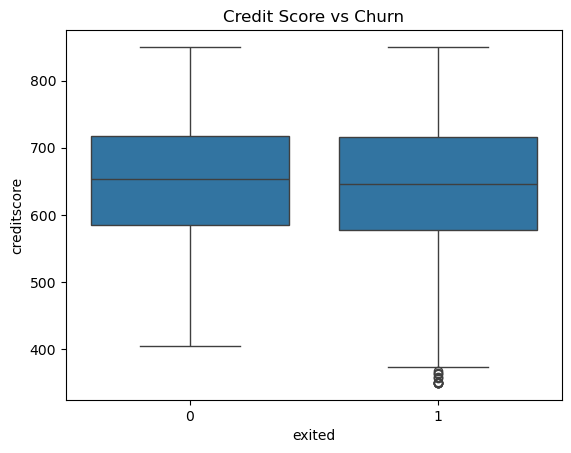

In [30]:
sns.boxplot(x='exited', y='creditscore', data=df)
plt.title("Credit Score vs Churn")
plt.show()

### Insight:

Customers with lower credit scores tend to churn more frequently, indicating financial instability or dissatisfaction.

Credit score plays a moderate role in churn prediction and should be considered alongside other behavioral factors.

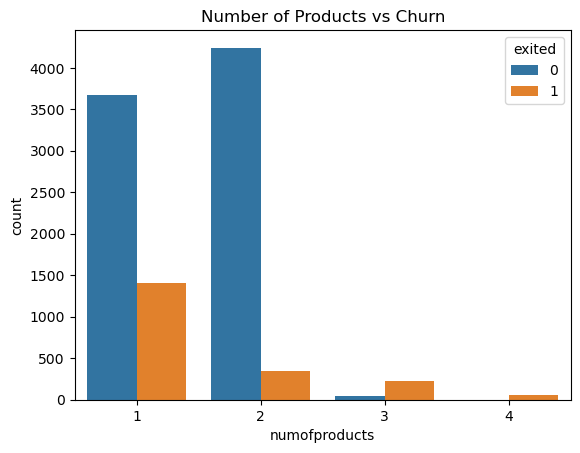

In [31]:
sns.countplot(x='numofproducts', hue='exited', data=df)
plt.title("Number of Products vs Churn")
plt.show()

### Insight:

Customers with fewer products are more likely to churn.

This suggests lower engagement with bank services. Increasing cross-selling opportunities can help reduce churn probability.

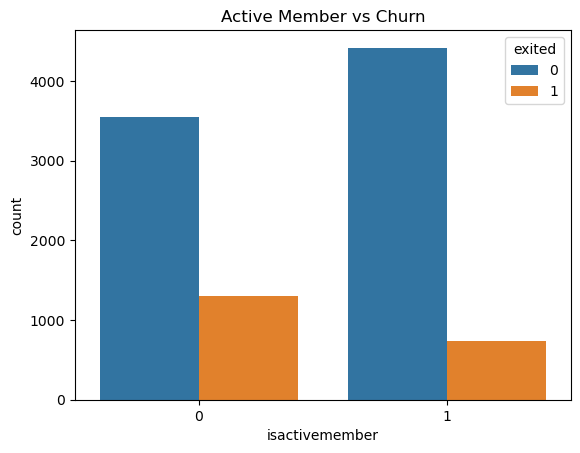

In [32]:
sns.countplot(x='isactivemember', hue='exited', data=df)
plt.title("Active Member vs Churn")
plt.show()

### Insight:

Inactive customers are significantly more likely to churn.

Customer engagement is a strong indicator of retention, making it a critical factor for churn prediction.

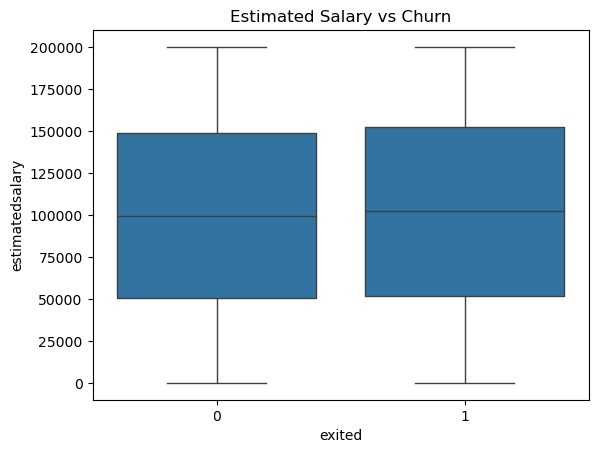

In [34]:
sns.boxplot(x='exited', y='estimatedsalary', data=df)
plt.title("Estimated Salary vs Churn")
plt.show()

### Insight:

Estimated salary does not show a strong relationship with churn.

This indicates that income alone is not a key driver of customer retention and should not be heavily relied upon for prediction.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Logistic Regression → interpretable  
Random Forest → better performance but less interpretable

In [13]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

Scaling ensures all features contribute equally and improves convergence of Logistic Regression.

In [14]:
param_grid = {
    'model__C': [0.1, 1, 10]
}

grid = GridSearchCV(pipeline, param_grid, cv=5)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

In [15]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.811


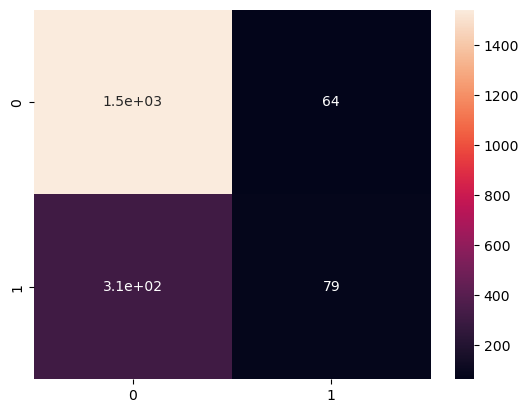

In [17]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.show()

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



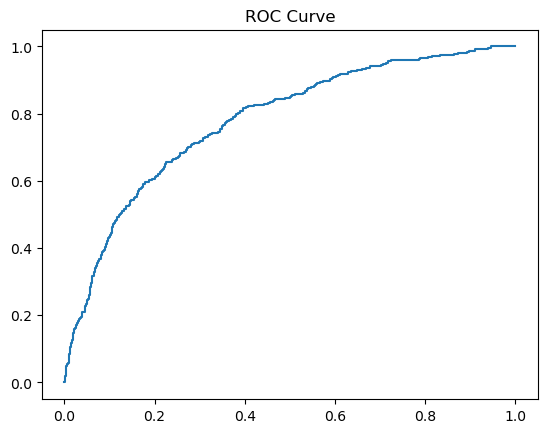

In [19]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.show()

In [20]:
print("AUC:", roc_auc_score(y_test, y_prob))

AUC: 0.7788919659694942


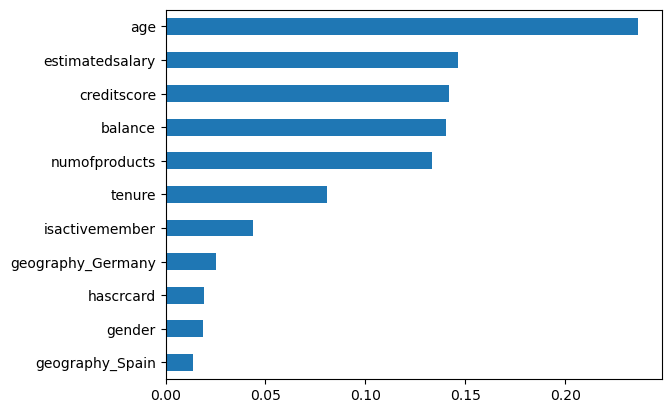

In [21]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.show()

Key drivers of churn include age, balance, and number of products.

## Key Insights

- Older customers are more likely to churn
- High balance customers are at higher risk
- Geography plays a significant role in churn behavior

## Business Recommendations

- Focus retention efforts on high-balance customers
- Target German region with improved services or offers
- Increase engagement of inactive users through campaigns
- Promote cross-selling to increase product usage

## Risk Analysis

False negatives (predicting a customer will stay when they leave) are more costly than false positives.

The model should prioritize identifying potential churners even at the cost of slight over-prediction.